# 탐색적 데이터 분석



In [2]:
# 데이터불러오기 / 헌혈건수 컬럼이름 맞추기

import pandas as pd
import os

base = r"c:\AI project\전처리"

files = [
    "age_clean.csv",
    "Bloodtype_clean.csv",
    "job_clean.csv",
    "location_clean.csv",
    "method_clean.csv",
    "month_clean.csv",
    "region_clean.csv",
    "stock_clean.csv",
    'year_clean.csv'
]

BD = {}

for file in files:
    path = os.path.join(base, file)
    
    print("loading:", path)
    
    df = pd.read_csv(path)
    
    df = df.rename(columns={'건': '헌혈건수'})
    
    BD[file] = df

loading: c:\AI project\전처리\age_clean.csv
loading: c:\AI project\전처리\Bloodtype_clean.csv
loading: c:\AI project\전처리\job_clean.csv
loading: c:\AI project\전처리\location_clean.csv
loading: c:\AI project\전처리\method_clean.csv
loading: c:\AI project\전처리\month_clean.csv
loading: c:\AI project\전처리\region_clean.csv
loading: c:\AI project\전처리\stock_clean.csv
loading: c:\AI project\전처리\year_clean.csv


In [3]:
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

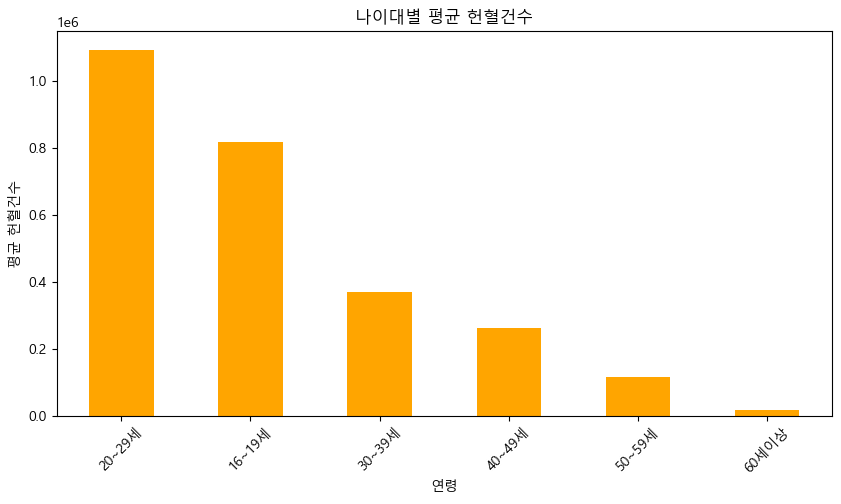

In [4]:

# ========================================================================
# AGE 
# ========================================================================
BD['age_clean.csv'].head()
BD['age_clean.csv'].isnull().sum()

BD['age_clean.csv'].columns
# 연령코드', '연령대', '기준연도', '헌혈건수'
age = BD['age_clean.csv']

# 가장 많은 헌혈나이대
age_group = age.groupby('연령대')['헌혈건수'].mean().sort_values(ascending=False)

# 그래프
plt.figure(figsize=(10,5))
age_group.plot(kind='bar',color='orange')

plt.title('나이대별 평균 헌혈건수')
plt.xlabel('연령')
plt.ylabel('평균 헌혈건수')
plt.xticks(rotation=45)
plt.show()

# 20,미성년자,30대 순서

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 160 entries, 0 to 159
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   직업명     160 non-null    object
 1   직업코드    160 non-null    object
 2   기준연도    160 non-null    int64 
 3   헌혈건수    160 non-null    int64 
dtypes: int64(2), object(2)
memory usage: 5.1+ KB


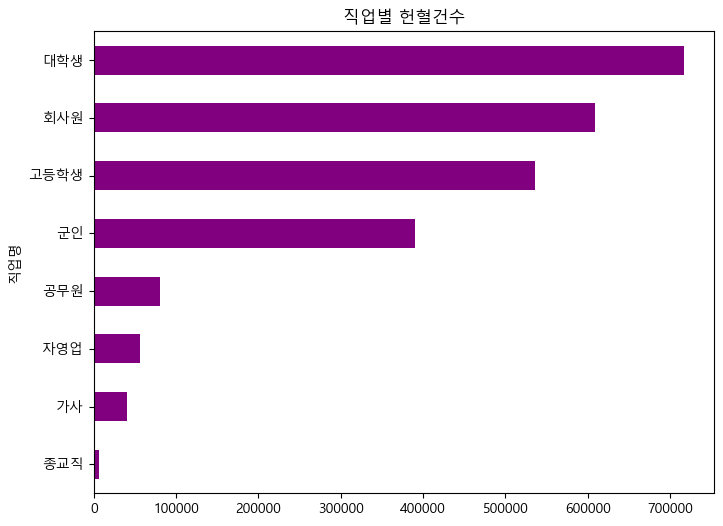

Empty DataFrame
Columns: [직업명, 직업코드, 기준연도, 헌혈건수]
Index: []
이상치 개수: 0


In [6]:
# ===============================
# JOB
# ===============================

job = BD["job_clean.csv"]
job.head()
job.info()
job.describe()
job.isnull().sum()

# 직업별 헌혈평균 그래프확인
job_group = job.groupby("직업명")["헌혈건수"].mean().sort_values()
job_group.head(10)

job_group.plot(kind='barh', figsize=(8,6),color='purple')
plt.title('직업별 헌혈건수')
plt.show()


# 이상치 확인(이상치 x)
Q1 = job["헌혈건수"].quantile(0.25)
Q3 = job["헌혈건수"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = job[
    (job["헌혈건수"] < lower) |
    (job["헌혈건수"] > upper)
]

print(outliers)
print("이상치 개수:", len(outliers))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7308 entries, 0 to 7307
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   혈액보유량   7306 non-null   float64
 1   월       7308 non-null   int64  
dtypes: float64(1), int64(1)
memory usage: 114.3 KB


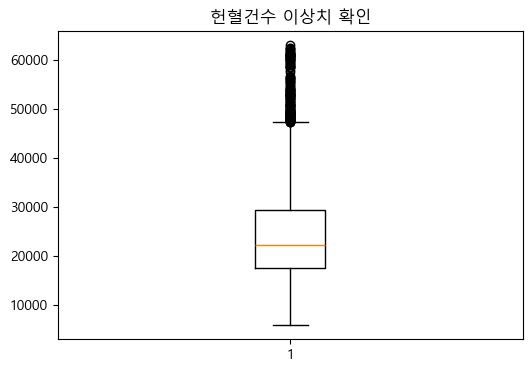

월
3    19159.117742
Name: 혈액보유량, dtype: float64

In [ ]:
# ========================================================================
# STOCK
# ========================================================================
stock = BD["stock_clean.csv"]

stock.head()
stock.info()
stock.isnull().sum() # 2

# 혈액보유량 결측치 평균값 대체
stock['혈액보유량'] = stock['혈액보유량'].fillna(stock['혈액보유량'].mean())
# stock.isnull().sum() 
stock.describe()
# plt.plot(stock['혈액보유량'])




# 혈액보유량 그래프 이상치확인
plt.figure(figsize=(6,4))

plt.boxplot(stock["혈액보유량"])

plt.title("헌혈건수 이상치 확인")
plt.show()

# ====================================
# 혈액 보유가 제일 적은 달 
# ====================================
stock_month = stock.groupby("월")["혈액보유량"].mean()

stock_month.sort_values().head(1)


## 혈액보유량평균 24220
# std	9431.309793 표준편차가 큼(불안정)
# 혈액보유 가장 적은달 3월 

In [ ]:
stock.describe()

# std 높음(공급불안)
# max,min 값의 차이가 매우큼

,혈액보유량,월
count,7308.000000,7308.000000
mean,24220.516014,6.521073
std,9431.309793,3.449448
min,5809.000000,1.000000
25%,17433.000000,4.000000
50%,22220.000000,7.000000
75%,29397.250000,10.000000
max,63001.000000,12.000000


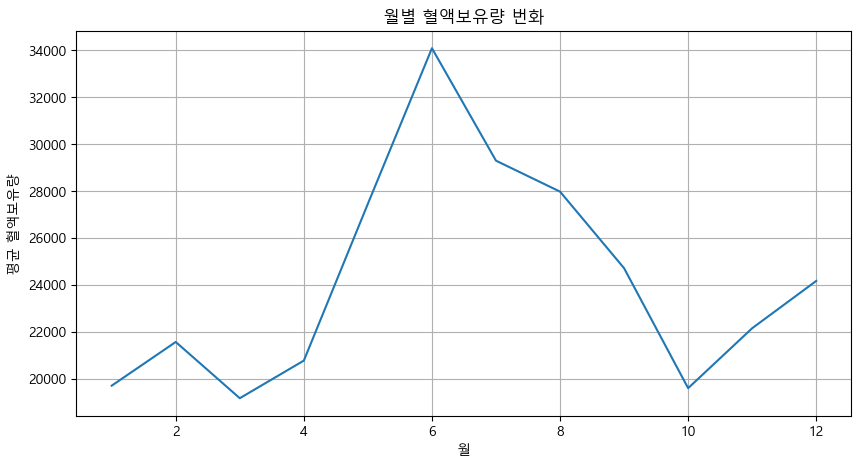

In [ ]:

stocks = BD["stock_clean.csv"]

monthly_stock = stocks.groupby("월")["혈액보유량"].mean()

# 평균
plt.figure(figsize=(10,5))
monthly_stock.plot()

plt.title('월별 혈액보유량 번화')
plt.xlabel("월")
plt.ylabel("평균 혈액보유량")
plt.grid()
plt.show()

# 6~7월 가장높음
# 3,10월 적음


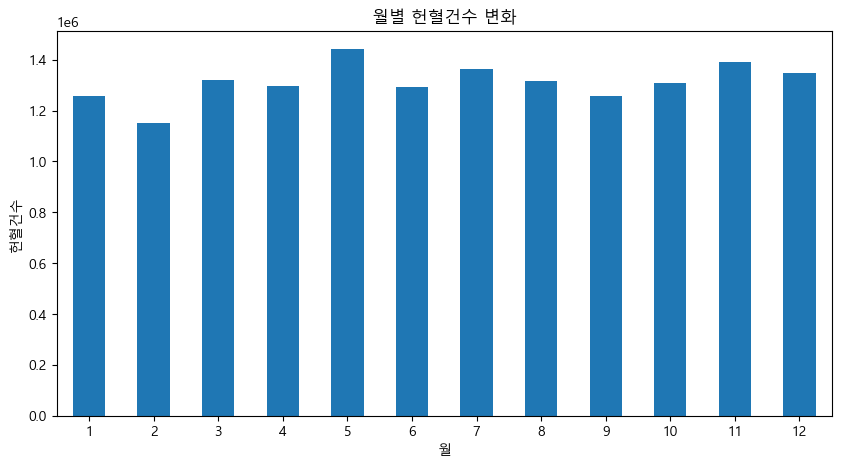

월
2    1150373.3
1    1257821.4
9    1258032.0
6    1292791.6
4    1295732.4
Name: 헌혈건수, dtype: float64

In [ ]:
# ===========================
# MONTH
# ===========================

month = BD['month_clean.csv']
month.head()
month.tail()
month['연도'].unique()
month.columns 
#연도', '월', '헌혈건수

# 월별그래프

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

month_group = month.groupby("월")["헌혈건수"].mean()
month_group
plt.figure(figsize=(10,5))

month_group.plot(kind='bar')

plt.title('월별 헌혈건수 변화')
plt.xlabel("월")
plt.ylabel("헌혈건수")
plt.xticks(rotation=0)
plt.show()

month_sort = month_group.sort_values(ascending=True).head()
month_sort
#11~1월은 헌혈참여율이 감소할것이다(활동저하)
# 2,1,9,6,4 순서 

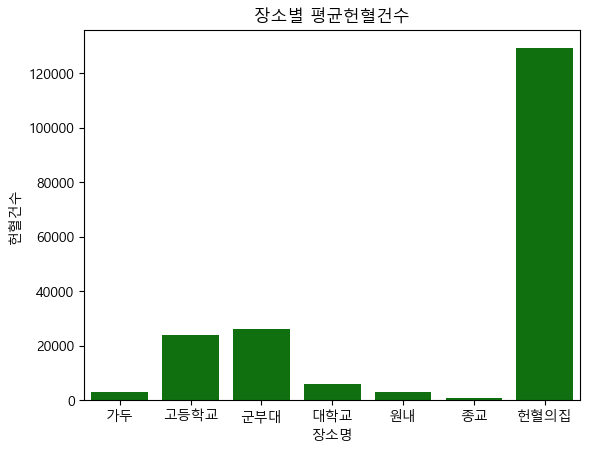

장소명
헌혈의집    129164.331288
군부대      25913.124744
고등학교     23713.815951
대학교       5967.946830
원내        3110.605317
가두        2992.871166
종교         909.002045
Name: 헌혈건수, dtype: float64

In [ ]:
# ========================================
# location
# ========================================

location = BD['location_clean.csv']
location.head()
location_group = location.groupby('장소명')['헌혈건수'].mean()

import seaborn as sns
sns.barplot(location_group,color='green')
plt.title('장소별 평균헌혈건수')
plt.show()

sort_location =location_group.sort_values(ascending=False)
sort_location

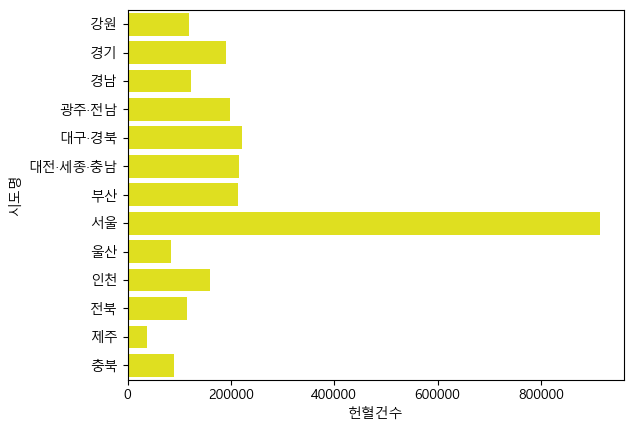

7     914588.55
4     222253.90
5     214767.80
6     214608.25
3     197476.60
1     190896.00
9     159183.50
2     122495.20
0     118067.80
10    114304.85
12     90367.60
8      84032.00
11     37073.80
Name: 헌혈건수, dtype: float64

In [ ]:
# ======================================
# region
# ======================================
region = BD['region_clean.csv']
region.describe()

region_groupby= region.groupby('시도명')['헌혈건수'].mean().reset_index()
sns.barplot(x=region_groupby['헌혈건수'],y=region_groupby['시도명'],color='yellow')
plt.show()

region_sort  = region_groupby['헌혈건수'].sort_values(ascending=False)
region_sort

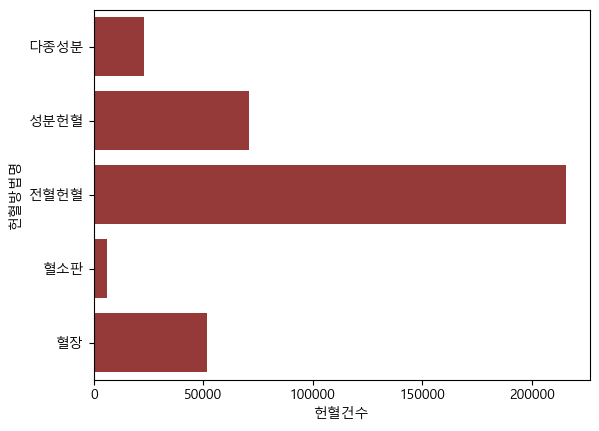

2    215798.550091
1     71102.575592
4     51797.446575
0     23092.420561
3      5883.693989
Name: 헌혈건수, dtype: float64

In [ ]:
# ======================================
# method
# ======================================

method = BD['method_clean.csv']


method['헌혈건수'] = pd.to_numeric(
    method['헌혈건수'],
    errors='coerce'
)

method_groupby= method.groupby('헌혈방법명')['헌혈건수'].mean().reset_index()
sns.barplot(x=method_groupby['헌혈건수'],y=method_groupby['헌혈방법명'],color='brown')
plt.show()

method_sort  = method_groupby['헌혈건수'].sort_values(ascending=False)
method_sort

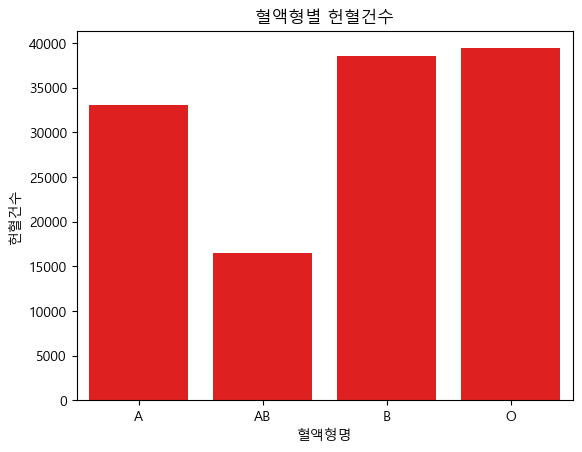

In [ ]:
# ======================================
# bloodtype
# ======================================

bt = BD['Bloodtype_clean.csv']
bt.head()

bt['헌혈건수'] = pd.to_numeric(
    bt['헌혈건수'],
    errors='coerce'
)
bt_g = bt.groupby('혈액형명')['헌혈건수'].mean().reset_index()

sns.barplot(x=bt_g['혈액형명'],y=bt_g['헌혈건수'],color='red')
plt.title('혈액형별 헌혈건수')
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

import seaborn as sns


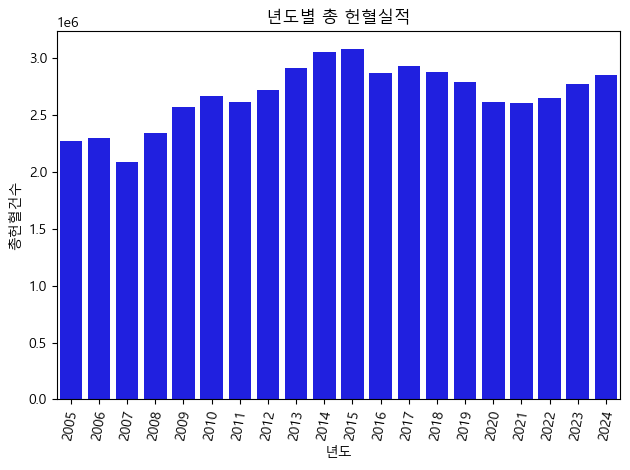

In [ ]:
# =====================
# year
# =====================
year = pd.read_csv('./전처리2/year2.csv')
year.columns

# 총헌혈실적 그래프확인

sns.barplot(x=year['년도'],y=year['총헌혈건수'],color='blue')
plt.title('년도별 총 헌혈실적')
plt.xlabel('년도')
plt.ylabel('총헌혈건수')
plt.xticks(rotation=80)
plt.tight_layout()
plt.show()

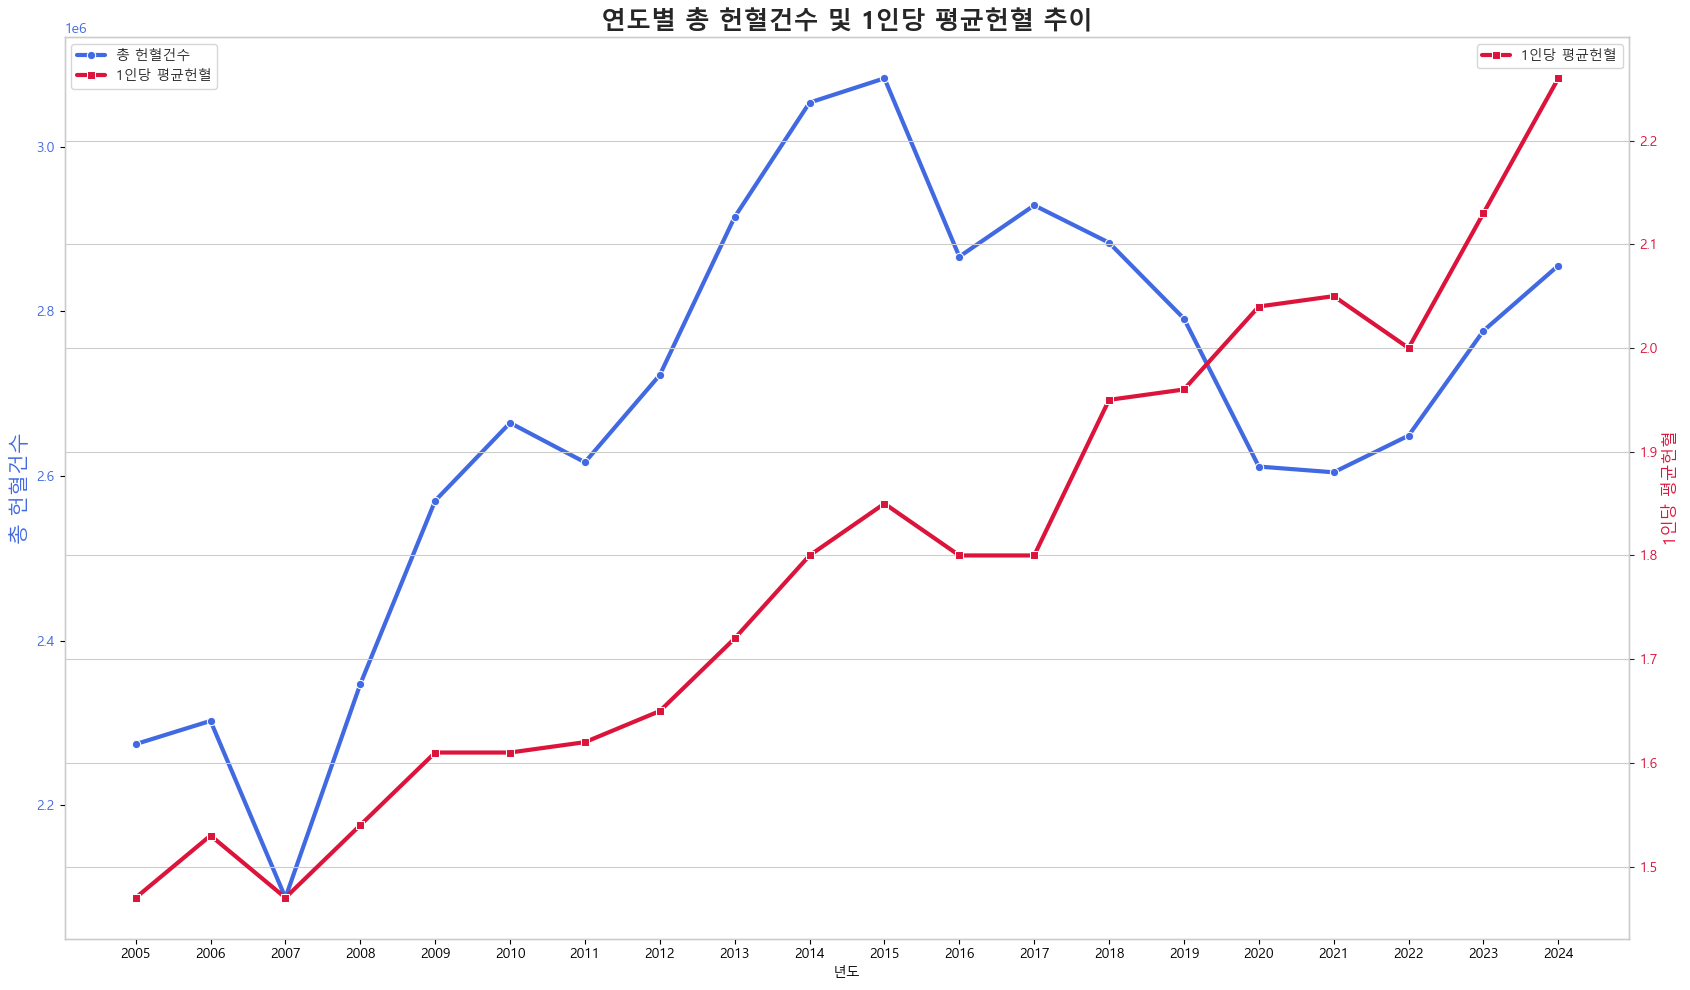

In [ ]:
fig, ax1 = plt.subplots(figsize=(17, 10))

import matplotlib.pyplot as plt
import seaborn as sns

# seaborn 스타일 먼저
sns.set_style('whitegrid')

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# ---------------------------
# 총 헌혈건수
# ---------------------------
sns.lineplot(
    data=year,
    x='년도',
    y='총헌혈건수',
    marker='o',
    color='royalblue',
    linewidth=3,
    label='총 헌혈건수',
    ax=ax1
)

ax1.set_ylabel('총 헌혈건수', fontsize=15, color='royalblue')
ax1.tick_params(axis='y', labelcolor='royalblue')

# ---------------------------
# 1인당 평균헌혈
# ---------------------------
ax2 = ax1.twinx()

sns.lineplot(
    data=year,
    x='년도',
    y='1인당평균헌혈',
    marker='s',
    color='crimson',
    linewidth=3,
    label='1인당 평균헌혈',
    ax=ax2
)

ax2.set_ylabel('1인당 평균헌혈', fontsize=12, color='crimson')
ax2.tick_params(axis='y', labelcolor='crimson')

# ---------------------------
# x축 설정
# ---------------------------
plt.xticks(
    ticks=year['년도'],
    rotation=45
)

# 제목
plt.title(
    '연도별 총 헌혈건수 및 1인당 평균헌혈 추이',
    fontsize=18,
    fontweight='bold'
)

# 범례 합치기
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc='upper left'
)

plt.tight_layout()
plt.show()

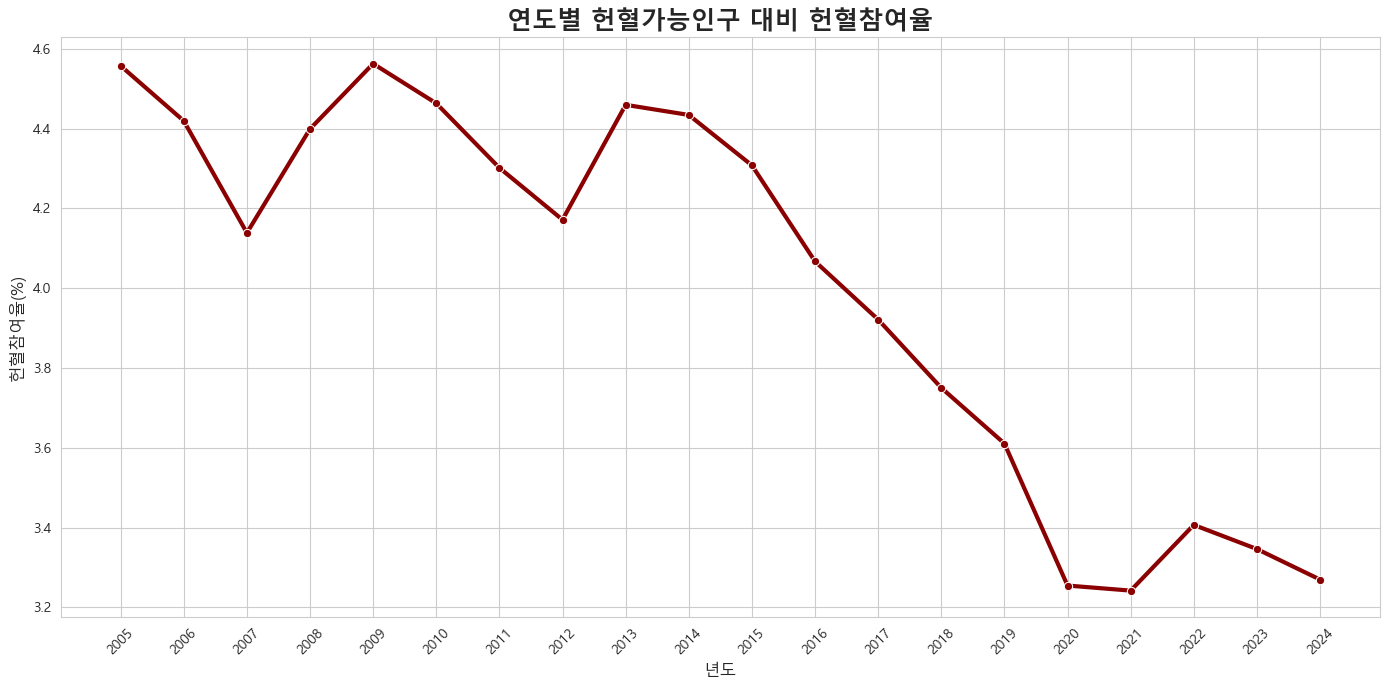

In [ ]:
#  헌혈 참여율 계산
year['헌혈참여율'] = (
    year['헌혈자수'] / year['헌혈가능인구']
) * 100

# 스타일
sns.set_style('whitegrid')

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False


# 그래프 크기
plt.figure(figsize=(14, 7))

# 라인 그래프
sns.lineplot(
    data=year,
    x='년도',
    y='헌혈참여율',
    marker='o',
    linewidth=3,
    color='darkred'
)

# 제목
plt.title(
    '연도별 헌혈가능인구 대비 헌혈참여율',
    fontsize=18,
    fontweight='bold'
)

# 축 라벨
plt.xlabel('년도', fontsize=12)
plt.ylabel('헌혈참여율(%)', fontsize=12)

# x축 회전
plt.xticks(
    ticks=year['년도'],
    rotation=45
)

plt.tight_layout()
plt.show()